In [5]:
#.VERİ LİSTESİ OLUŞTURMAK İÇİN GREKLİ OLAN KODALR

!pip install faker

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from faker import Faker
from datetime import datetime, timedelta

# Türkçe isimler ve veriler oluşturmak için kütüphane
fake = Faker('tr_TR')

# --- Ön Hazırlık Listeleri ---
sehir_listesi = [fake.city() for _ in range(80)]
meslek_listesi = [fake.job() for _ in range(50)]

# Popüler Araba Markaları Havuzu
araba_markalari = ["Fiat", "Renault", "Ford", "Toyota", "Volkswagen", "Hyundai", "Honda", "Opel", "Peugeot", "BMW", "Mercedes"]

# Sigorta Türleri
sigorta_turleri = ["Trafik", "Kasko", "Trafik ve Kasko", "Dask", "Konut", "Dask ve Konut"]

satir_sayisi = 1000
data = []

for _ in range(satir_sayisi):
    # 1. Kişisel Bilgiler
    isim = fake.name()
    sehir = random.choice(sehir_listesi)
    meslek = random.choice(meslek_listesi)

    # 2. Sigorta Türü Seçimi
    sigorta_turu = random.choice(sigorta_turleri)


    # Eğer sigorta türünde Trafik veya Kasko geçiyorsa araba bilgisi ekle, yoksa boş bırak
    if "Trafik" in sigorta_turu or "Kasko" in sigorta_turu:
        araba_markasi = random.choice(araba_markalari)
        araba_yili = random.randint(2005, 2025)
    else:
        araba_markasi = np.nan  # Veri yok anlamında (Not a Number)
        araba_yili = np.nan

    # 4. Fiyatlandırma Mantığı
    if sigorta_turu == "Trafik":
        police_degeri = random.randint(6000, 10000)
    elif sigorta_turu == "Kasko":
        police_degeri = random.randint(8000, 12000)
    elif sigorta_turu == "Trafik ve Kasko":
        police_degeri = random.randint(14000, 22000)
    elif sigorta_turu == "Dask":
        police_degeri = random.randint(5000, 7000)
    elif sigorta_turu == "Konut":
        police_degeri = random.randint(6000, 8000)
    elif sigorta_turu == "Dask ve Konut":
        police_degeri = random.randint(11000, 15000)
    else:
        police_degeri = 0

    # 5. Komisyon
    komisyon_orani = random.randint(8, 20)
    komisyon_tutari = police_degeri * (komisyon_orani / 100)

    # 6. Tarih
    gun_farki = random.randint(0, 365)
    tarih = datetime.now() - timedelta(days=gun_farki)
    tarih_str = tarih.strftime('%d.%m.%Y')

    # 7. Yenileme Yılı
    yenileme = random.randint(0, 10)

    # 8. Referans
    referans_var_mi = random.choices([True, False], weights=[70, 30])[0]
    referans = fake.name() if referans_var_mi else "Yok"


    # Önce: Bu kişi poliçeyi satın aldı mı?
    satin_aldi_mi = random.choices([True, False], weights=[85, 15])[0]

    if satin_aldi_mi:
        # Satın aldıysa: İptal etti mi?
        iptal_mi = random.choices([True, False], weights=[20, 80])[0]
        if iptal_mi:
            durum = "İptal Edildi"
        else:
            durum = "Aktif"
    else:
        durum = "Satın Alınmadı" # Teklif aşamasında kalmış

    # Listeye ekle
    data.append([
        isim,
        sehir,
        meslek,
        sigorta_turu,
        araba_markasi,
        araba_yili,
        police_degeri,
        komisyon_orani,
        round(komisyon_tutari, 2),
        tarih_str,
        yenileme,
        referans,
        durum
    ])

# DataFrame oluşturma
musteriList = pd.DataFrame(data, columns=[
    'İsim Soyisim',
    'Şehir',
    'Meslek',
    'Sigorta Türü',
    'Araba Markası',
    'Araç Model Yılı',
    'Poliçe Değeri (TL)',
    'Komisyon Oranı (%)',
    'Komisyon Tutarı (TL)',
    'İşlem Tarihi',
    'Yenileme Yılı',
    'Referans',
    'Poliçe Durumu'
])


In [6]:
musteriList

,İsim Soyisim,Şehir,Meslek,Sigorta Türü,Araba Markası,Araç Model Yılı,Poliçe Değeri (TL),Komisyon Oranı (%),Komisyon Tutarı (TL),İşlem Tarihi,Yenileme Yılı,Referans,Poliçe Durumu
0,Uz. Ismık Bilge,North Çakar,Yer gösterici,Dask ve Konut,NaN,NaN,13283,9,1195.47,25.10.2025,5,Yok,İptal Edildi
1,Dr. Sedife Yıldırım Fırat,Port Çoğay,Makasçı,Trafik,Ford,2018.0,7962,19,1512.78,03.10.2025,1,Necva Ülker,Aktif
2,Tahir Korutürk,South Gürardafort,Kürkçü,Dask,NaN,NaN,5513,8,441.04,01.05.2025,3,Cevale Zorlu,İptal Edildi
3,Faize Zengin,Durduland,Teknoloji uzmani,Konut,NaN,NaN,7413,11,815.43,19.12.2025,1,Günkurt Kete Zengin Sakarya,Aktif
4,Almast Minibe Yıldırım Arslan,North Sabiheville,Galerici,Trafik,Hyundai,2012.0,7017,15,1052.55,31.03.2025,3,Av. Gülözge Amre Kısakürek,Aktif
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Derkay Erkılıç Korutürk,Alparslanmouth,Jeomorfolog,Konut,NaN,NaN,6800,8,544.00,04.10.2025,3,Doç. Özyurt Çamurcuoğlu Tevetoğlu,İptal Edildi
996,Dr. Yalın Ülker Mansız,Port Zülgarnimouth,İthalatçı,Konut,NaN,NaN,6397,10,639.70,10.09.2025,6,Ferihan Soylu,Aktif
997,Refik Akçabay Mansız,Sevenville,Obuacı,Trafik,Peugeot,2018.0,7585,14,1061.90,11.10.2025,9,Deryanur Duran,Aktif
998,Okt. Necva Gülter Durdu,Gülhaven,Teknoloji uzmani,Trafik ve Kasko,BMW,2007.0,17101,14,2394.14,18.06.2025,3,Yok,Aktif


Küme Özellikleri (Ortalama Değerler):
                                    Poliçe Değeri (TL)  Komisyon Oranı (%)  \
Segment İsimleri                                                            
Premium (Trafik+Kasko) Müşteriler            16765.62               13.23   
Sadık Temel Müşteriler                        8352.24               17.23   
Yüksek Komisyonlu Yeni Müşteriler             8071.64               10.49   

                                   Yenileme Yılı  
Segment İsimleri                                  
Premium (Trafik+Kasko) Müşteriler           5.22  
Sadık Temel Müşteriler                      5.04  
Yüksek Komisyonlu Yeni Müşteriler           4.52  


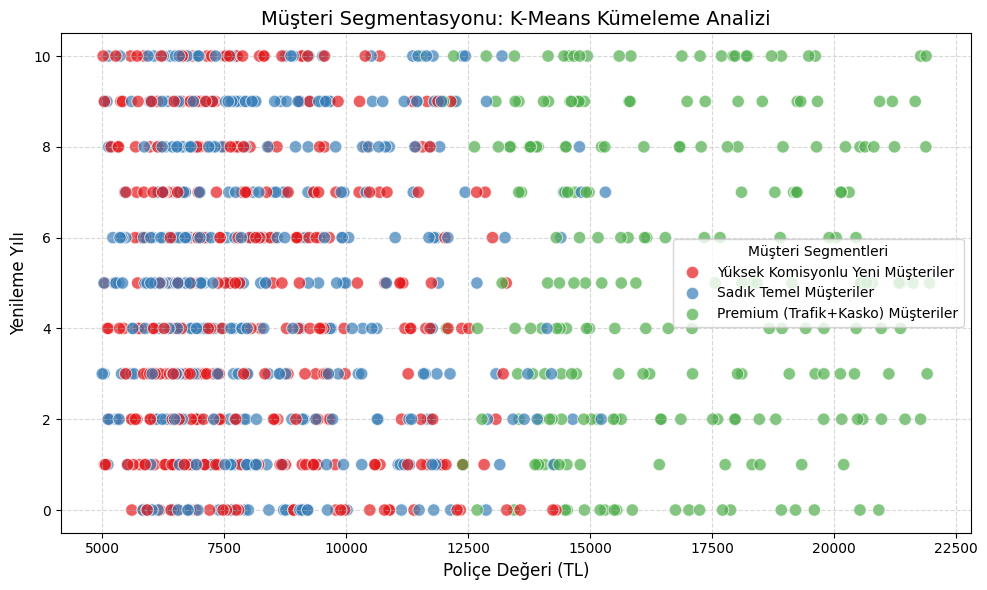

In [7]:
# K-Means ve Ölçeklendirme için gerekli kütüphaneleri ekliyoruz
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# --- MÜŞTERİ SEGMENTASYONU (K-MEANS) ---

# 1. K-Means için sadece anlamlı sayısal (numerik) verileri seçiyoruz.
features = ['Poliçe Değeri (TL)', 'Komisyon Oranı (%)', 'Yenileme Yılı']
X = musteriList[features]

# 2. Verileri Standartlaştırma (Çok Önemli!)
# Poliçe değerleri binlerle, komisyon ve yenileme yılı ise 0-20 arasında.
# Algoritmanın büyük sayılara aldanmaması için aynı ölçeğe getiriyoruz.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means Modelini Oluşturma ve Eğitme
# Müşterileri 3 farklı segmente ayıralım (n_clusters = 3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
musteriList['Müşteri Segmenti (Küme)'] = kmeans.fit_predict(X_scaled)

# 4. Kümeleri (Segmentleri) İsimlendirme
cluster_names = {0: 'Yüksek Komisyonlu Yeni Müşteriler',
                 1: 'Premium (Trafik+Kasko) Müşteriler',
                 2: 'Sadık Temel Müşteriler'}
musteriList['Segment İsimleri'] = musteriList['Müşteri Segmenti (Küme)'].map(cluster_names)

# Kümelerin ortalama değerlerini inceleyelim
cluster_summary = musteriList.groupby('Segment İsimleri')[features].mean().round(2)
print("Küme Özellikleri (Ortalama Değerler):\n", cluster_summary)

# --- GÖRSELLEŞTİRME ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=musteriList,
    x='Poliçe Değeri (TL)',
    y='Yenileme Yılı',
    hue='Segment İsimleri',
    palette='Set1',
    alpha=0.7,
    s=80
)
plt.title('Müşteri Segmentasyonu: K-Means Kümeleme Analizi', fontsize=14)
plt.xlabel('Poliçe Değeri (TL)', fontsize=12)
plt.ylabel('Yenileme Yılı', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Müşteri Segmentleri')
plt.tight_layout()
plt.show()